In [76]:
import h3

import sys

import cartopy
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import einops
import numpy as np
import sys
sys.path.insert(0, "/user/work/ef17148/oldstuff/ef17148/.conda/envs/GCN_env/lib/python3.8/site-packages/")
import torch

from model.layers.encoder import *
from model.layers.decoder import *
from model.layers.processor import *
from model.layers.graph_net_block import *
from model.data.dataloader_graphnet import *
from model.data.load_data import *
from model.forecast import GraphSatelliteForecaster
import torch.optim as optim
import pytorch_lightning as pl
from sklearn.metrics import mean_squared_error, r2_score
import time
import os
import pickle

# load data

In [8]:
# load train and test data to train a model
data = LoadSatelliteData(year="201[4-5]", region="BRAZIL", freq=10, metsize=50, size =50, topog="default", verbose=True, cut_met = False, met_datadir="/group/chemistry/acrg/met_archive/UM/cut_SOUTHAMERICA_big/Met_cut_v2_50_")

Loading footprint data from /group/chemistry/acrg/LPDM/fp_NAME_pre20210701/SOUTHAMERICA/*BRAZIL*SOUTHAMERICA_201[4-5]*.nc
checking bad files
at least one of the files was in the bad files list, opening with workaround
10 33920
reduced the number of datapoints by frequency 10
3392
Cutting footprints to size
41 footprints were at least partially filled with nans because they were cutting outside of the footprint file domain (this is 1.21% of samples)
footprints that are partially out of the domain in each direction: {'N': 0, 'S': 0, 'E': 41, 'W': 0}
maximum out-of-domain index in each direction: {'N': 0, 'S': 0, 'E': 192, 'W': 0}
(3392, 2500) 3392
Loading meteorology from /group/chemistry/acrg/met_archive/UM/cut_SOUTHAMERICA_big/Met_cut_v2_50_201[4-5]*.nc
not cutting met, just checking
reducing time frequency of met too
cut_met was passed as false. Met will be used as is
Note that because met has been passed pre-cut, if fp and original met had different sizes fp will not be cut!
(3392, 2

/user/work/ef17148/oldstuff/ef17148/.conda/envs/GCN_env/lib/python3.8/site-packages/xarray/core/missing.py:562: FutureWarning: Passing method to DatetimeIndex.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.
  imin = index.get_loc(minval, method="nearest")
/user/work/ef17148/oldstuff/ef17148/.conda/envs/GCN_env/lib/python3.8/site-packages/xarray/core/missing.py:563: FutureWarning: Passing method to DatetimeIndex.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.
  imax = index.get_loc(maxval, method="nearest")


(3392, 2500) 3392


/user/work/ef17148/oldstuff/ef17148/.conda/envs/GCN_env/lib/python3.8/site-packages/xarray/core/missing.py:562: FutureWarning: Passing method to DatetimeIndex.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.
  imin = index.get_loc(minval, method="nearest")
/user/work/ef17148/oldstuff/ef17148/.conda/envs/GCN_env/lib/python3.8/site-packages/xarray/core/missing.py:563: FutureWarning: Passing method to DatetimeIndex.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.
  imax = index.get_loc(maxval, method="nearest")


There are 41 nans in the met data. finding and deleting from met and fp (only on axis time)
(3351, 2500) 3351
3351
loading topography from /group/chemistry/acrg/LPDM/topog_NAME/TopogUMG_Mk8_global.nc


/user/work/ef17148/oldstuff/ef17148/.conda/envs/GCN_env/lib/python3.8/site-packages/xarray/core/missing.py:562: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.
  imin = index.get_loc(minval, method="nearest")
/user/work/ef17148/oldstuff/ef17148/.conda/envs/GCN_env/lib/python3.8/site-packages/xarray/core/missing.py:563: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.
  imax = index.get_loc(maxval, method="nearest")
/user/work/ef17148/oldstuff/ef17148/.conda/envs/GCN_env/lib/python3.8/site-packages/xarray/core/missing.py:562: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.
  imin = index.get_loc(minval, method="nearest")
/user/work/ef17148/oldstuff/ef17148/.conda/envs/GCN_

All data loaded


In [28]:
# you can load test data only if you are going to predict from a trained and saved model
test_data = LoadSatelliteData(year=201601, region="BRAZIL", metsize=50, size =50, topog="default", verbose=True, cut_met = False, met_datadir="/group/chemistry/acrg/met_archive/UM/cut_SOUTHAMERICA_big/Met_cut_v2_50_")

Loading footprint data from /group/chemistry/acrg/LPDM/fp_NAME_pre20210701/SOUTHAMERICA/*BRAZIL*SOUTHAMERICA_201601*.nc
1 1438
1438
Cutting footprints to size
28 footprints were at least partially filled with nans because they were cutting outside of the footprint file domain (this is 1.95% of samples)
footprints that are partially out of the domain in each direction: {'N': 0, 'S': 0, 'E': 28, 'W': 0}
maximum out-of-domain index in each direction: {'N': 0, 'S': 0, 'E': 192, 'W': 0}
(1438, 2500) 1438
Loading meteorology from /group/chemistry/acrg/met_archive/UM/cut_SOUTHAMERICA_big/Met_cut_v2_50_201601*.nc
not cutting met, just checking
cut_met was passed as false. Met will be used as is
Note that because met has been passed pre-cut, if fp and original met had different sizes fp will not be cut!
(1438, 2500) 1438
(1438, 2500) 1438
There are 28 nans in the met data. finding and deleting from met and fp (only on axis time)
(1410, 2500) 1410
1410
loading topography from /group/chemistry/ac

/user/work/ef17148/oldstuff/ef17148/.conda/envs/GCN_env/lib/python3.8/site-packages/xarray/core/missing.py:562: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.
  imin = index.get_loc(minval, method="nearest")
/user/work/ef17148/oldstuff/ef17148/.conda/envs/GCN_env/lib/python3.8/site-packages/xarray/core/missing.py:563: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.
  imax = index.get_loc(maxval, method="nearest")
/user/work/ef17148/oldstuff/ef17148/.conda/envs/GCN_env/lib/python3.8/site-packages/xarray/core/missing.py:562: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.
  imin = index.get_loc(minval, method="nearest")
/user/work/ef17148/oldstuff/ef17148/.conda/envs/GCN_

In [29]:
preds_100 = xr.load_dataset("/user/work/ef17148/GCN/graphnet/graph_weather/trained_satellite_models_fixedmet/satellite_fixedmet_loss_satellite1_clever2_100_[6,12]_vB/predictions/preds_201601.nc")
test_data, preds_100 = align_datasets_with_xr(test_data, preds_100)

In [30]:
# to train, set up both the training and testing datasets manually
# skip to "predicting" if not training
others =["sin_lat_coords", "sin_lon_coords", "cos_lat_coords", "cos_lon_coords", "lat_coords", "lon_coords", "distance_centre", "x_coords", "y_coords"]
topog=True
variables_with_past = {"x_wind":[3,9,15,21,30,42,51], "wind_speed":[3,30,51], "wind_angle":[3,30,51], "y_wind":[3,9,15,21,30,42,51], "upward_air_velocity":[3,9,15,21,30,42,51], "air_temperature":[3,9,15,21,30,42,51], "air_pressure":[3,9,15,21,30,42,51], "atmosphere_boundary_layer_thickness":[0], "surface_air_pressure":[0]}
jumps = [6,12]
variables_without_past = {}

In [10]:
grid, idx_grid, inputs, names, data = get_all_inputs_graphnet_satellite_v4(data, variables_with_past, jumps, variables_without_past, topog=topog, others=others, return_idx=True)

hours back in time: [0, 6]
3351
3351
0 3351
6 3351


/user/work/ef17148/oldstuff/ef17148/.conda/envs/GCN_env/lib/python3.8/site-packages/xarray/core/missing.py:562: FutureWarning: Passing method to DatetimeIndex.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.
  imin = index.get_loc(minval, method="nearest")
/user/work/ef17148/oldstuff/ef17148/.conda/envs/GCN_env/lib/python3.8/site-packages/xarray/core/missing.py:563: FutureWarning: Passing method to DatetimeIndex.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.
  imax = index.get_loc(maxval, method="nearest")


(50, 50, 3351)


In [11]:
_, _, test_inputs, _, test_data = get_all_inputs_graphnet_satellite_v4(test_data, {"x_wind":[3,9,15,21,30,42,51], "wind_speed":[3,30,51], "wind_angle":[3,30,51], "y_wind":[3,9,15,21,30,42,51], "upward_air_velocity":[3,9,15,21,30,42,51], "air_temperature":[3,9,15,21,30,42,51], "air_pressure":[3,9,15,21,30,42,51], "atmosphere_boundary_layer_thickness":[0], "surface_air_pressure":[0]}, [6], {}, topog=topog, others=others, return_idx=True)

hours back in time: [0, 6]
2128
2128
0 2128
6 2128


/user/work/ef17148/oldstuff/ef17148/.conda/envs/GCN_env/lib/python3.8/site-packages/xarray/core/missing.py:562: FutureWarning: Passing method to DatetimeIndex.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.
  imin = index.get_loc(minval, method="nearest")
/user/work/ef17148/oldstuff/ef17148/.conda/envs/GCN_env/lib/python3.8/site-packages/xarray/core/missing.py:563: FutureWarning: Passing method to DatetimeIndex.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.
  imax = index.get_loc(maxval, method="nearest")


(50, 50, 2128)


In [12]:
train_dataset = FootprintsDataset(np.copy(inputs), np.copy(data.fp_data), standardise=False, transform_output="boxcox", feature_dim=np.shape(inputs)[-1]-len(others)-topog, aux_dim=len(others)+topog, zeroing=True,  clever_transform_2=True, input_names=names)
train_loader = DataLoader(train_dataset, batch_size=5, shuffle=True)

zeroing


In [13]:
test_dataset = FootprintsDataset(np.copy(test_inputs), np.copy(test_data.fp_data), standardise=False, transform_output="boxcox", feature_dim=np.shape(inputs)[-1]-len(others)-topog, aux_dim=len(others)+topog, zeroing=True,  clever_transform_2=True, input_names=names, test_mode={"clever_transformers":train_dataset.transformers,  "boxcox":train_dataset.boxcox})
test_loader = DataLoader(test_dataset, batch_size=10, shuffle=False)

zeroing


# load model - predicting

A trained model will have saved the footprint reference grid used for training, any transformers (for both the input and output data) and model parameters so you don't have to load the training data

In [67]:
path="/user/work/ef17148/GCN/graphnet/graphnet_LPDM_emulator/trained_models/"
model_name = "satellite_50x50_default"

#path="/user/work/ef17148/GCN/graphnet/graph_weather/trained_satellite_models_fixedmet/"
#model_name = "satellite_fixedmet_loss_satellite1_clever2_verybig_[6,12]_vB_notimevars"

with open(f"{path}{model_name}/grid_{model_name}.pickle", 'rb') as f:
    grid = pickle.load(f)
with open(f"{path}{model_name}/transformers_{model_name}.pickle", 'rb') as f:
    test_mode = pickle.load(f)

with open(f"{path}{model_name}/params_{model_name}.pickle", 'rb') as f:
    params = pickle.load(f)


/user/work/ef17148/oldstuff/ef17148/.conda/envs/GCN_env/lib/python3.8/site-packages/sklearn/base.py:329: UserWarning: Trying to unpickle estimator StandardScaler from version 0.24.1 when using version 1.0.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/modules/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/user/work/ef17148/oldstuff/ef17148/.conda/envs/GCN_env/lib/python3.8/site-packages/sklearn/base.py:329: UserWarning: Trying to unpickle estimator PowerTransformer from version 0.24.1 when using version 1.0.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/modules/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [33]:
_, idx_grid, test_inputs, _, test_data = get_all_inputs_graphnet_satellite_v4(test_data, **params["input_params"], return_idx=True)

hours back in time: [0, 6, 12]
314
314
0 314
6 314
12 314
(50, 50, 314)


In [90]:
test_dataset = FootprintsDataset(np.copy(test_inputs), np.copy(test_data.fp_data), **params["dataset_params"], test_mode=test_mode)
test_loader = DataLoader(test_dataset, batch_size=10, shuffle=False)

zeroing


In [92]:
test_dataset.standardise_inputs

False

In [70]:
# load checkpoint
def getint(name):
    num = name.split('_')[-1]
    num = num.split('.')[0]
    return int(num)

files = sorted(glob.glob(glob.escape(f"{path}{model_name}/{model_name}_")+"*.pt"), key=getint)
checkpoint_to_load = files[-1] 
checkpoint = torch.load(checkpoint_to_load, map_location=torch.device('cpu'))

model = GraphSatelliteForecaster(grid, **params["model_params"])
optimizer = optim.AdamW(model.parameters(), lr=checkpoint["learning_rate"])


optimizer = optim.AdamW(model.parameters(), lr=checkpoint["learning_rate"])
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

in satellite encoder!


/user/work/ef17148/oldstuff/ef17148/.conda/envs/graphnet/lib/python3.8/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The input object of type 'Tensor' is an array-like implementing one of the corresponding protocols (`__array__`, `__array_interface__` or `__array_struct__`); but not a sequence (or 0-D). In the future, this object will be coerced as if it was first converted using `np.array(obj)`. To retain the old behaviour, you have to either modify the type 'Tensor', or assign to an empty array created with `np.empty(correct_shape, dtype=object)`.
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/user/work/ef17148/oldstuff/ef17148/.conda/envs/graphnet/lib/python3.8/site-packages/numpy/core/fromnumeric.py:86: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the 

set up processor
set up decoder


In [71]:
preds = model(test_dataset.inputs).detach().numpy()
transformed_preds = test_dataset.inverse_transform(np.squeeze(preds))

/tmp/ipykernel_197260/1105370540.py:17: RuntimeWarning: divide by zero encountered in log10
  ax[2].imshow(np.log10(np.reshape(c, (test_data.size,test_data.size))))
/tmp/ipykernel_197260/1105370540.py:19: RuntimeWarning: divide by zero encountered in log10
  ax[3].imshow(np.log10(np.reshape(test_dataset.fp_untransformed[n,:], (test_data.size,test_data.size))))


Text(0.5, 1.0, '50x50 truth \n (original space)')

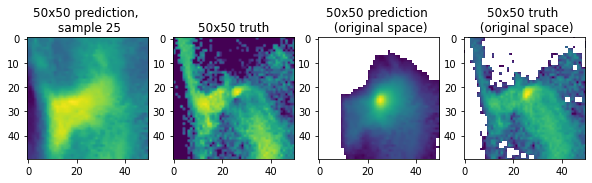

In [72]:
# plot footprint
fig, ax = plt.subplots(1,4, figsize=(10,15))
try:
    n=n+5
except:
    n=0
ax[0].imshow(np.reshape(preds[n,:,0], (test_data.size,test_data.size)))
ax[0].set_title(f"50x50 prediction, \n sample {n}")
ax[1].imshow(np.reshape(test_dataset.fp[n,:,0], (test_data.size,test_data.size)))
ax[1].set_title("50x50 truth")

# remove low values to get plot looking closer to the original (not needed numerically, only visually)
c = np.copy(transformed_preds[n,:])
c[c<0.0001] = 0

# plot original space in log10
ax[2].imshow(np.log10(np.reshape(c, (test_data.size,test_data.size))))
ax[2].set_title("50x50 prediction \n (original space)")
ax[3].imshow(np.log10(np.reshape(test_dataset.fp_untransformed[n,:], (test_data.size,test_data.size))))
ax[3].set_title("50x50 truth \n (original space)")


# load model - training

In [14]:
# loss function: punishes underprediction more than overprediction by weighting under predictions by a factor of alpha, then applies MSE
class MSE_assymetric(nn.Module):
    def __init__(self, alpha=4):
        self.alpha=alpha
        super().__init__()
        

    def forward(self, output, target):
        loss=target-output
        loss[loss>0] = self.alpha*loss[loss>0]
        loss = torch.mean(loss**2)
        return loss

In [19]:
lr=5e-5
test_batch_size=10
model_params = {"whole_world":False, "feature_dim":np.shape(inputs)[-1]-len(others)-topog, "aux_dim":len(others)+topog,"num_blocks":4, "node_dim":64, "edge_dim":64, "hidden_layers_processor_node":3, "hidden_layers_processor_edge":2,  "hidden_layers_decoder":1, "hidden_dim_processor_node":16, "hidden_dim_processor_edge":16, "hidden_dim_decoder":16, "resolution":4, "output_dim":1, "residuals":False}

model = GraphSatelliteForecaster(grid, **model_params)

in satellite encoder!


/user/work/ef17148/oldstuff/ef17148/.conda/envs/graphnet/lib/python3.8/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The input object of type 'Tensor' is an array-like implementing one of the corresponding protocols (`__array__`, `__array_interface__` or `__array_struct__`); but not a sequence (or 0-D). In the future, this object will be coerced as if it was first converted using `np.array(obj)`. To retain the old behaviour, you have to either modify the type 'Tensor', or assign to an empty array created with `np.empty(correct_shape, dtype=object)`.
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/user/work/ef17148/oldstuff/ef17148/.conda/envs/graphnet/lib/python3.8/site-packages/numpy/core/fromnumeric.py:86: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the 

set up processor
set up decoder


In [20]:
criterion=MSE_assymetric(alpha=2)
criterion_test = torch.nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=lr)

losses = {"train":[], "test":[], "NMAE_test":[], "MSE_test_transformed":[], "NMAE_test_transformed":[]}

epoch_so_far = 0
device="cpu"

Start Epoch: 0
[0,     1] loss: 0.326 Time: 0.21922755241394043 sec
[0,    11] loss: 0.279 Time: 1.8395507335662842 sec
[0,    21] loss: 0.283 Time: 3.33630633354187 sec
[0,    31] loss: 0.285 Time: 4.754136085510254 sec
[0,    41] loss: 0.284 Time: 6.351921796798706 sec
[0,    51] loss: 0.286 Time: 7.817551374435425 sec
[0,    61] loss: 0.292 Time: 9.265307664871216 sec
[0,    71] loss: 0.294 Time: 10.66232419013977 sec
[0,    81] loss: 0.295 Time: 12.126935720443726 sec
[0,    91] loss: 0.299 Time: 13.552484512329102 sec
[0,   101] loss: 0.303 Time: 14.98761510848999 sec
[0,   111] loss: 0.309 Time: 16.421910524368286 sec
[0,   121] loss: 0.310 Time: 17.827417612075806 sec
[0,   131] loss: 0.315 Time: 19.212129592895508 sec
[0,   141] loss: 0.320 Time: 20.624521017074585 sec
[0,   151] loss: 0.324 Time: 22.18355417251587 sec
[0,   161] loss: 0.329 Time: 23.59908628463745 sec
[0,   171] loss: 0.334 Time: 25.023710012435913 sec
[0,   181] loss: 0.337 Time: 26.441396236419678 sec
[0,   

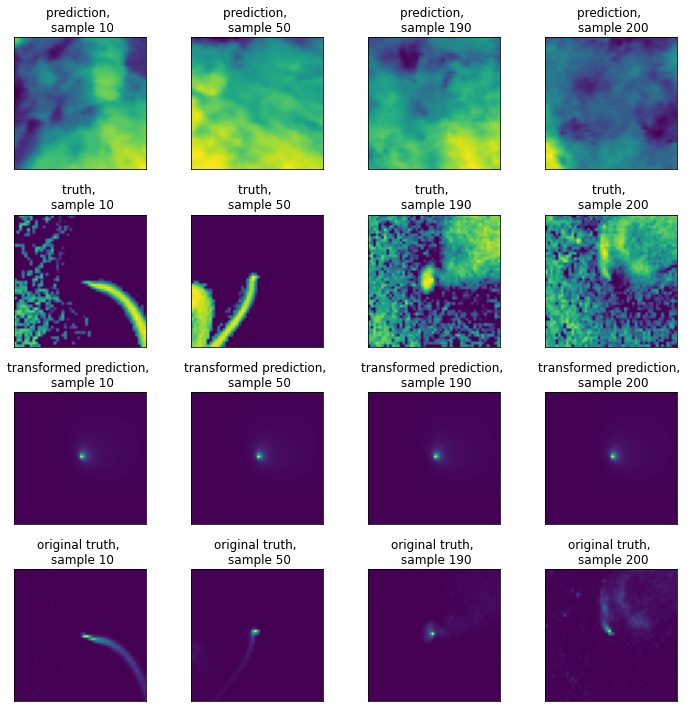

Start Epoch: 1
[1,     1] loss: 0.371 Time: 0.16939759254455566 sec
[1,    11] loss: 0.417 Time: 1.669884204864502 sec
[1,    21] loss: 0.392 Time: 3.1420841217041016 sec
[1,    31] loss: 0.380 Time: 4.638884544372559 sec
[1,    41] loss: 0.379 Time: 6.071124076843262 sec
[1,    51] loss: 0.381 Time: 7.599324703216553 sec
[1,    61] loss: 0.383 Time: 9.048147201538086 sec
[1,    71] loss: 0.383 Time: 10.47911810874939 sec
[1,    81] loss: 0.386 Time: 11.918190956115723 sec
[1,    91] loss: 0.389 Time: 13.388235569000244 sec
[1,   101] loss: 0.391 Time: 14.905800104141235 sec
[1,   111] loss: 0.393 Time: 16.372254848480225 sec
[1,   121] loss: 0.394 Time: 17.900237798690796 sec
[1,   131] loss: 0.392 Time: 19.268582344055176 sec
[1,   141] loss: 0.391 Time: 20.712599277496338 sec
[1,   151] loss: 0.393 Time: 22.18256425857544 sec
[1,   161] loss: 0.394 Time: 23.608604431152344 sec
[1,   171] loss: 0.393 Time: 25.08090901374817 sec
[1,   181] loss: 0.393 Time: 26.58381962776184 sec
[1,  

In [21]:
torch.manual_seed(33)

for epoch in range(2): 
    epoch=epoch+epoch_so_far
    running_loss = 0.0
    print(f"Start Epoch: {epoch}")
    start = time.time()
    for i, batch in enumerate(train_loader):
        ins, labels = batch[0].to(device), batch[1].to(device)
        optimizer.zero_grad()

        outputs = model(ins)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        loss = criterion_test(outputs, labels)
        running_loss += loss.item()
        end = time.time()
        del outputs 
        if i % 10==0:
            print(f"[{epoch}, {i + 1:5d}] loss: {running_loss / (i + 1):.3f} Time: {end - start} sec")
    
    test_error = 0.0
    test_out = np.zeros((test_dataset.inputs.size()[0], test_dataset.inputs.size()[1]))   
    for i_test, batch in enumerate(test_loader):
        ins, labels = batch[0].to(device), batch[1].to(device)
        test_error += criterion_test(model(ins), labels).item()
        test_out[i_test*test_batch_size:(i_test+1)*test_batch_size,:] = np.squeeze(model(ins).detach().cpu().numpy())
    
    
    losses["train"].append(running_loss/(i+1))
    losses["test"].append(test_error/(i_test+1))

    truths = torch.squeeze(test_dataset.fp).detach().numpy()
    print(f"NMAE: {NMAE(test_out,truths)}")
    losses["NMAE_test"].append(NMAE(test_out,truths))
    transformed_preds = test_dataset.inverse_transform(test_out)
    NMAE_trans, mse = test_dataset.prediction_error()
    losses["NMAE_test_transformed"].append(NMAE_trans)
    losses["MSE_test_transformed"].append(mse)

    if epoch % 5 == 0:
        n=0
        og_fps = test_dataset.fp_untransformed
        fps = test_dataset.fp.detach().numpy()
        fig, ax = plt.subplots(4,4, figsize=(10, 10))
        for axis, fn in enumerate([10,50,190,200]):
            ax[0,axis].imshow(np.reshape(test_dataset.predictions[fn+n,:], (data.size,data.size)), origin="lower")
            ax[1,axis].imshow(np.reshape(fps[fn+n,:], (data.size,data.size)), origin="lower") 
            ax[2,axis].imshow(np.reshape(transformed_preds[fn+n,:], (data.size,data.size)), origin="lower")
            ax[3,axis].imshow(np.reshape(og_fps[fn+n,:], (data.size,data.size)), origin="lower")   
            ax[0,axis].set_title(f"prediction, \n sample {fn+n}")
            ax[1,axis].set_title(f"truth, \n sample {fn+n}")
            ax[2,axis].set_title(f"transformed prediction, \n sample {fn+n}")
            ax[3,axis].set_title(f"original truth, \n sample {fn+n}")
            for a in range(4):
                ax[a,axis].xaxis.set_ticks([])
                ax[a,axis].yaxis.set_ticks([])

        plt.tight_layout()
        plt.show()

epoch_so_far = epoch